## Lab 1: Random Network

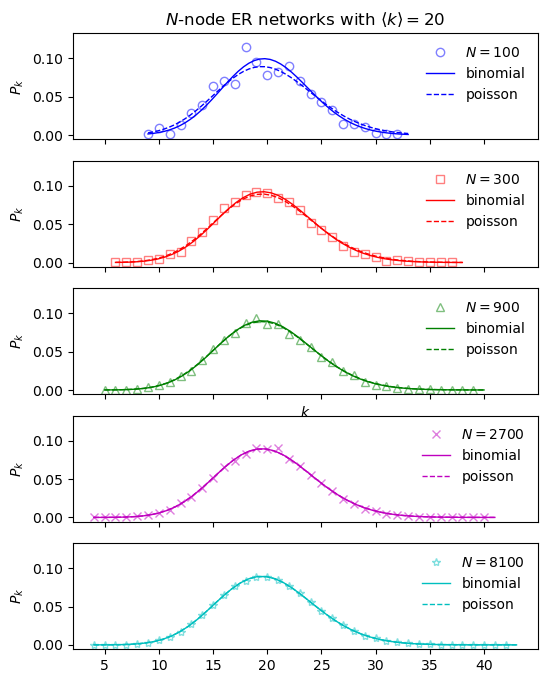

In [19]:
from scipy.special import comb, factorial as F
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# part(a)
er_func = nx.erdos_renyi_graph     # O(N^2)
er_fast = nx.fast_gnp_random_graph # O(N+E)

trials, kAvg = 10, 20 # average degree〈k〉= 20. 
fig, ax = plt.subplots(
    5, 1, sharex=True, sharey=True, figsize=(6, 8))

for i, (a, N) in enumerate(zip(ax, [100,300,900,2700,8100])):
    fmt = ['bo', 'rs', 'g^','mx', 'c*'][i]
    degs = [k for t in range(trials) for n, k in
            er_fast(N, kAvg/(N-1), seed= 3042 + t).degree] # set different seed for every trail
    kMin, kMax = min(degs), max(degs)
    a.plot(range(kMin, kMax+1), (np.bincount(degs)/(N*trials))[kMin:kMax+1],
           fmt, mfc='none', alpha=.5, label='$N=%d$'%N)
    
    ks = np.linspace(kMin, kMax+1) # keep ks as an integar
    p = kAvg/(N-1)
    a.plot(ks, comb(N-1,ks)*p**ks*(1-p)**(N-1-ks),
           fmt[0], lw=1, label='binomial')
    a.plot(ks, kAvg**ks/F(ks)*np.exp(-kAvg),
           fmt[0]+'--', lw=1, label='poisson')
    a.set_ylabel('$P_k$')
    a.legend(loc=1, frameon=False)

ax[2].set_xlabel('$k$')
ax[0].set_ylim(a.get_ylim()[0], a.get_ylim()[1]*1.1)
ax[0].set_title(r'$N$-node ER networks with $\langle{k}\rangle=%d$'%kAvg)
plt.show()

     N      ⟨L⟩     ln N   theory
------------------------------------
   100    1.820    4.605    1.537
   300    2.186    5.704    1.904
   900    2.607    6.802    2.271
  2700    2.913    7.901    2.637
  8100    3.317    9.000    3.004


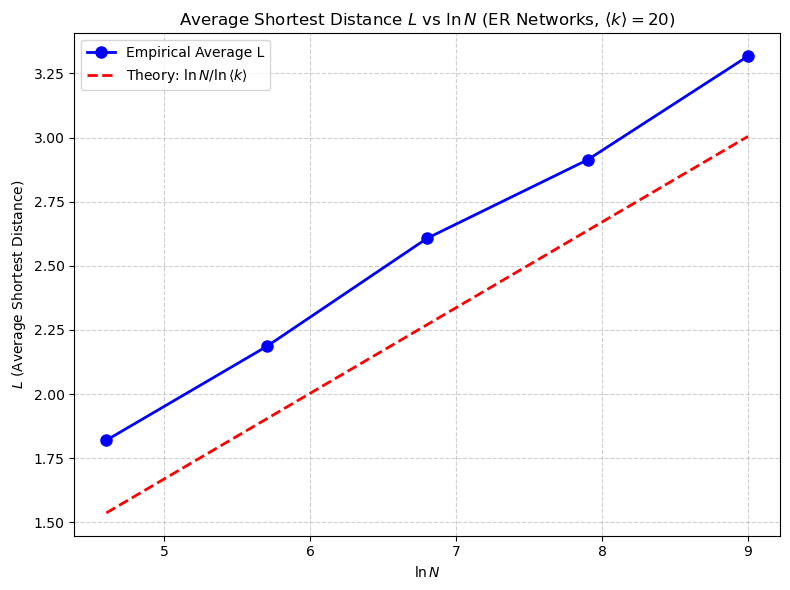

In [24]:
# part(b)
kAvg = 20  
N_list = [100, 300, 900, 2700, 8100]  
trials = 5  # Reduced for efficiency at large N

# Lists to store data for plotting
L_vals_mean = []
lnN_vals = []
theory_vals = []

print(f"{'N':>6} {'⟨L⟩':>8} {'ln N':>8} {'theory':>8}")
print("-" * 36)

results = []
for N in N_list:
    p = kAvg / (N - 1)  # Calculate edge probability p
    L_vals_trial = []  # Store L for each trial of this N
    
    for t in range(trials):
        G = nx.fast_gnp_random_graph(N, p, seed= 3042 + t)  
        
        # Handle disconnected graphs by using the giant component
        if not nx.is_connected(G):
            giant = max(nx.connected_components(G), key=len)
            G = G.subgraph(giant).copy()
        
        # Calculate average shortest path length for the (giant) component
        L = nx.average_shortest_path_length(G)
        L_vals_trial.append(L)
    
    # Average over trials for this N
    L_mean = np.mean(L_vals_trial)
    lnN = np.log(N)
    theory = np.log(N) / np.log(kAvg)
    
    # Print results
    print(f"{N:6d} {L_mean:8.3f} {lnN:8.3f} {theory:8.3f}")
    
    # Store for plotting
    L_vals_mean.append(L_mean)
    lnN_vals.append(lnN)
    theory_vals.append(theory)
    results.append((N, L_mean, lnN, theory))

# --- Plotting Section ---
plt.figure(figsize=(8, 6))
plt.plot(lnN_vals, L_vals_mean, 'bo-', label='Empirical Average L', markersize=8, linewidth=2)
plt.plot(lnN_vals, theory_vals, 'r--', label=r'Theory: $\ln N / \ln \langle k \rangle$', linewidth=2)

plt.xlabel(r'$\ln N$')
plt.ylabel(r'$L$ (Average Shortest Distance)')
plt.title(r'Average Shortest Distance $L$ vs $\ln N$ (ER Networks, $\langle k \rangle = 20$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()